In [7]:
import pandas as pd

# 1. Загружаем (убедись, что файл лежит в той же папке)
df = pd.read_csv('sample_data/student-mat.csv', sep=';') 

# 2. Создаем бинарный таргет
df["success"] = (df["G3"] >= 10).astype(int)

In [8]:
# Удаляем целевые колонки из признаков
X = df.drop(['success', 'G3'], axis=1)
y = df['success']

# Превращаем текст в колонки 0 и 1
X = pd.get_dummies(X, drop_first=True)

print(f"Количество признаков после обработки: {X.shape[1]}")

Количество признаков после обработки: 41


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
from sklearn.ensemble import RandomForestClassifier

# Инициализируем и обучаем
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Модель обучена!")

Модель обучена!


In [11]:
from sklearn.metrics import classification_report, accuracy_score

predictions = model.predict(X_test)

print(f"Точность модели: {accuracy_score(y_test, predictions):.2%}")
print("\nДетальный отчет:")
print(classification_report(y_test, predictions))

Точность модели: 92.41%

Детальный отчет:
              precision    recall  f1-score   support

           0       0.84      0.96      0.90        27
           1       0.98      0.90      0.94        52

    accuracy                           0.92        79
   macro avg       0.91      0.93      0.92        79
weighted avg       0.93      0.92      0.93        79



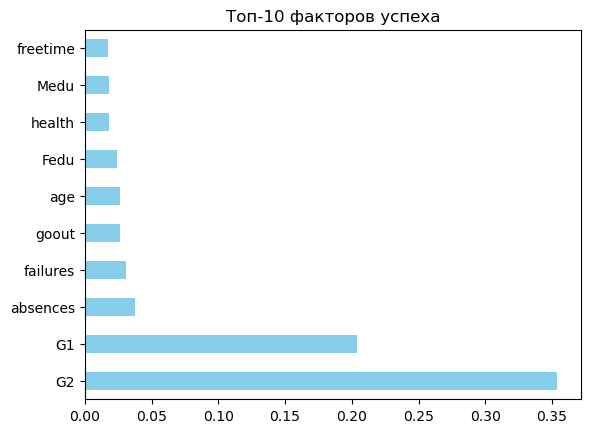

In [12]:
import matplotlib.pyplot as plt

# Берем важность признаков
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title("Топ-10 факторов успеха")
plt.show()